In [1]:
import numpy as np
import matplotlib.pyplot as plt

path = "unified_train_shuffled.npz"
data = np.load(path)

X = data["X"]  # shape (n_features, n_samples) -> flattened patches (HU values)
H = data["H"]  # shape (n_samples,) -> labels

print(f"X shape: {X.shape}, dtype: {X.dtype}")
print(f"H shape: {H.shape}, dtype: {H.dtype}")

X shape: (1728, 93985), dtype: float64
H shape: (93985,), dtype: int64


In [2]:
hu_values = X.ravel()

print("HU value statistics:")
print(f"  min:    {hu_values.min():.2f}")
print(f"  max:    {hu_values.max():.2f}")
print(f"  mean:   {hu_values.mean():.2f}")
print(f"  median: {np.median(hu_values):.2f}")
print(f"  std:    {hu_values.std():.2f}")

percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p:>3}%: {np.percentile(hu_values, p):.2f}")

HU value statistics:
  min:    -1.00
  max:    1.00
  mean:   -0.73


  median: -0.82


  std:    0.26

Percentiles:


    0%: -1.00


    1%: -1.00


...

   50%: -0.82


   75%: -0.66


   95%: -0.10


   99%: 0.04


  100%: 1.00


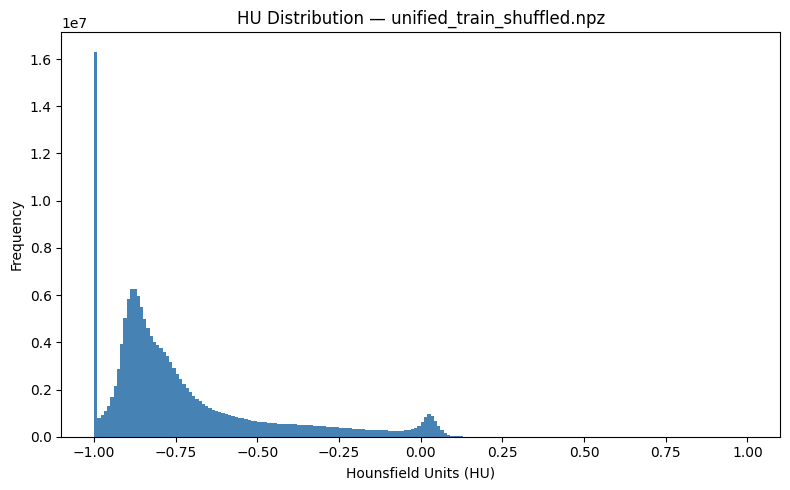

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(hu_values, bins=200, color="steelblue", edgecolor="none")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.title("HU Distribution \u2014 unified_train_shuffled.npz")
plt.tight_layout()
plt.show()

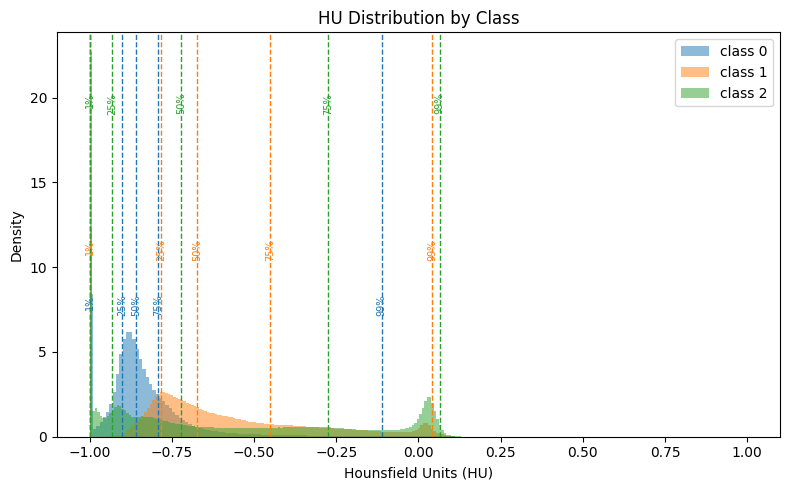

In [4]:
# Per-class HU distribution
classes = np.unique(H)
annotate_percentiles = [1, 25, 50, 75, 99]
colors = plt.cm.tab10.colors

plt.figure(figsize=(8, 5))
for i, c in enumerate(classes):
    vals = X[:, H == c].ravel()
    color = colors[i % len(colors)]
    plt.hist(vals, bins=200, alpha=0.5, label=f"class {c}", density=True, color=color)
    for p in annotate_percentiles:
        v = np.percentile(vals, p)
        plt.axvline(v, color=color, linestyle="--", linewidth=1)
        plt.text(v, plt.ylim()[1] * (0.95 - 0.05 * i), f"{p}%", color=color,
                  fontsize=7, ha="center", rotation=90, va="top")

plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Density")
plt.title("HU Distribution by Class")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2728861/620149355.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


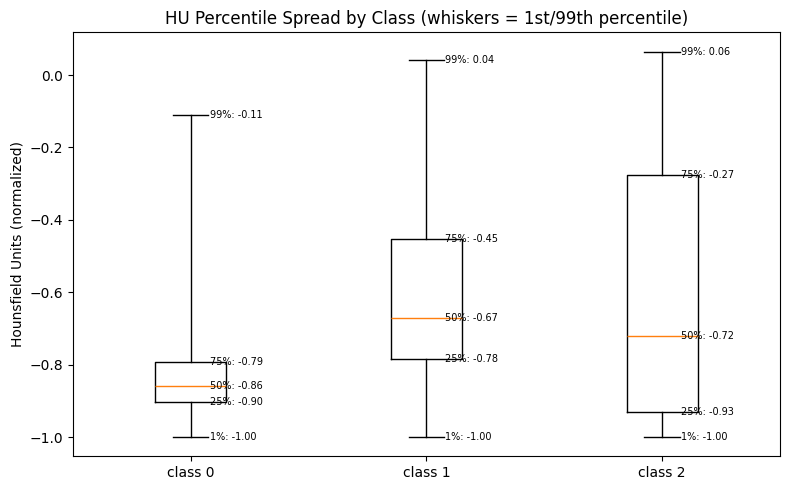

In [5]:
# Per-class boxplot (visualizes percentile spread)
plt.figure(figsize=(8, 5))
plt.boxplot(
    [X[:, H == c].ravel() for c in classes],
    labels=[f"class {c}" for c in classes],
    showfliers=False,
    whis=[1, 99],
)

annotate_percentiles = [1, 25, 50, 75, 99]
for i, c in enumerate(classes, start=1):
    vals = X[:, H == c].ravel()
    for p in annotate_percentiles:
        v = np.percentile(vals, p)
        plt.text(i + 0.08, v, f"{p}%: {v:.2f}", va="center", ha="left", fontsize=7)

plt.ylabel("Hounsfield Units (normalized)")
plt.title("HU Percentile Spread by Class (whiskers = 1st/99th percentile)")
plt.tight_layout()
plt.show()

In [6]:
# Per-class percentiles
percentiles = [1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99]

for c in classes:
    vals = X[:, H == c].ravel()
    print(f"Class {c} percentiles:")
    for p in percentiles:
        print(f"  {p:>3}%: {np.percentile(vals, p):.4f}")
    print()

Class 0 percentiles:


    1%: -1.0000


    2%: -1.0000


    5%: -1.0000


   10%: -0.9637


...

    5%: -1.0000
   10%: -1.0000


   25%: -0.9319


   50%: -0.7212
   75%: -0.2749


   90%: 0.0156
   95%: 0.0380


   98%: 0.0545
   99%: 0.0650



In [7]:
# X is normalized to [-1, 1]; original HU range was [-1000, 1000]
hu_values_real = X.ravel() * 1000

print("Original (denormalized) HU value statistics:")
print(f"  min:    {hu_values_real.min():.2f}")
print(f"  max:    {hu_values_real.max():.2f}")
print(f"  mean:   {hu_values_real.mean():.2f}")
print(f"  median: {np.median(hu_values_real):.2f}")
print(f"  std:    {hu_values_real.std():.2f}")

percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p:>3}%: {np.percentile(hu_values_real, p):.2f}")

Original (denormalized) HU value statistics:
  min:    -1000.00
  max:    1000.00
  mean:   -730.83


  median: -816.43


  std:    256.10

Percentiles:


    0%: -1000.00


    1%: -1000.00


...

   50%: -816.43


   75%: -661.25


   95%: -102.08


   99%: 42.48


  100%: 1000.00


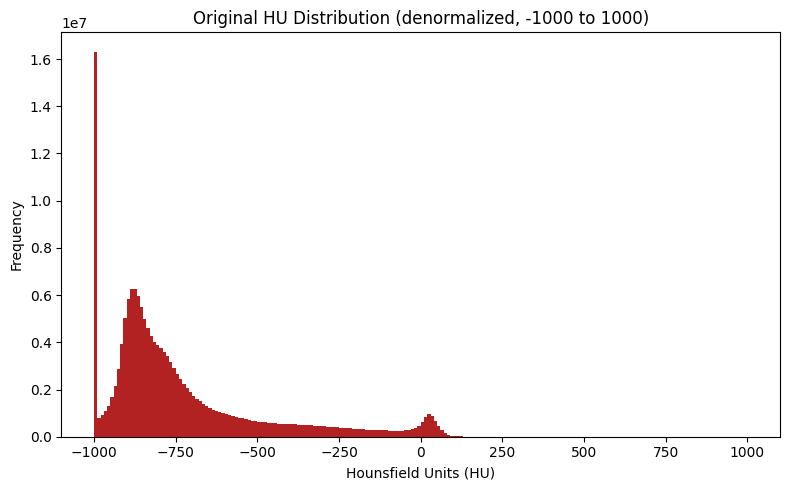

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(hu_values_real, bins=200, color="firebrick", edgecolor="none")
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.title("Original HU Distribution (denormalized, -1000 to 1000)")
plt.tight_layout()
plt.show()